<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/pytorch/shufflenet-v1-cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [ ]:
!pip install watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.4 MB/s eta 0:00:00


In [ ]:
!pip install torchinfo

In [ ]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



# ShuffleNetV1 Classifier on CIFAR-10

**Network Architecture:**

The network in this notebook is an implementation of the ShuffleNetV1 **[1]** architecture on the CIFAR-10 dataset to train an image classifier.  

![ShuffleNetV1-architecture](https://drive.google.com/uc?export=download&id=1tvp9iCSHaDAW461NNfQXdF2xFMivTJak)

[Image Source](https://arxiv.org/pdf/1707.01083)

---
### **ShuffleNetV1:** Unit Block

![ShuffleNet Unit-block](https://drive.google.com/uc?export=download&id=13eeekgoJX2hpGQU-RAYxfRGnnzXZh-wR)

[Image Source](https://arxiv.org/pdf/1707.01083)



<br><br>

---
**REFERENCES:**
1. Zhang, X., Zhou, X., Lin, M., & Sun, J. (2018). [ShuffleNet: An Extremely Efficient Convolutional Neural Network for Mobile Devices.](https://arxiv.org/abs/1707.01083) Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 6848-6856.
2. Johnson, J. (2022, February 2). _Lecture 11: CNN Architectures II_ [PowerPoint Slides]. University of Michigan EECS 498/598: Deep Learning for Computer Vision. pp 54-59. https://web.eecs.umich.edu/~justincj/slides/eecs498/WI2022/598_WI2022_lecture11.pdf

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [ ]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    torch.set_deterministic(True)

In [ ]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")

Num GPUs Available:  1
GPU 0: Tesla T4


---
# 0. Model Hyperparameters
---

In [ ]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
set_all_seeds(RANDOM_SEED)

---
# 1. Data Preparation & Loading

---

In [ ]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

# Data Augmentation (Crucial for VGG-16 on CIFAR-10)
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # Crop after padding
    transforms.RandomHorizontalFlip(),      # Flip
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Mean Subtraction
])

# Test/Validation Transforms (No Augmentation)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:05<00:00, 32.8MB/s]


In [ ]:
# Check that shuffling works properly
# i.e., label indices should be in random order.
# Also, the label order should be different in the second
# epoch.

for images, labels in train_loader:
    pass
print(labels[:10])

for images, labels in train_loader:
    pass
print(labels[:10])

tensor([1, 5, 5, 4, 2, 8, 5, 2, 4, 2])
tensor([9, 2, 4, 3, 7, 5, 8, 6, 2, 8])


In [ ]:
# Check that validation set and test sets are diverse
# i.e., that they contain all classes

for images, labels in val_loader:
    pass
print(labels[:10])

for images, labels in test_loader:
    pass
print(labels[:10])

tensor([1, 6, 5, 9, 9, 0, 6, 6])
tensor([7, 5, 8, 0, 8, 2, 7, 0, 3, 5])


---
# 2. Model Creation

---

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def channel_shuffle(x, groups):
    batchsize, num_channels, height, width = x.data.size()
    channels_per_group = num_channels // groups
    x = x.view(batchsize, groups, channels_per_group, height, width)     # Reshape
    x = torch.transpose(x, 1, 2).contiguous()                            # Transpose
    x = x.view(batchsize, -1, height, width)                             # Flatten back
    return x

class ShuffleUnitV1(nn.Module):
    def __init__(self, in_channels, out_channels, stride, groups):
        super(ShuffleUnitV1, self).__init__()
        self.stride = stride
        self.groups = groups
        mid_channels = out_channels // 4

        # If stride=2, the residual path includes an Average Pool and we concat,
        # so we must subtract in_channels from the output width.
        if self.stride == 2:
            out_channels -= in_channels

        # Group Convolution 1 (1x1)
        # Note: The original paper doesn't use groups in the first 1x1 of Stage 2
        self.gconv1 = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 1, groups=groups, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )

        # Depthwise Convolution (3x3)
        self.dwconv2 = nn.Sequential(
            nn.Conv2d(mid_channels, mid_channels, 3, stride, 1, groups=mid_channels, bias=False),
            nn.BatchNorm2d(mid_channels)
        )

        # Group Convolution 3 (1x1)
        self.gconv3 = nn.Sequential(
            nn.Conv2d(mid_channels, out_channels, 1, groups=groups, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        if stride == 2:
            self.shortcut = nn.AvgPool2d(3, stride=2, padding=1)

    def forward(self, x):
        residual = x

        out = self.gconv1(x)
        out = channel_shuffle(out, self.groups)
        out = self.dwconv2(out)
        out = self.gconv3(out)

        if self.stride == 2:
            res = self.shortcut(residual)
            out = F.relu(torch.cat([out, res], dim=1))
        else:
            out = F.relu(out + residual)

        return out

class ShuffleNetV1(nn.Module):
    def __init__(self, groups=3, num_classes=10):
        super(ShuffleNetV1, self).__init__()

        # Configuration for groups=3 (standard V1 setup)
        if groups == 1:
            out_channels = [24, 144, 288, 576]
        elif groups == 2:
            out_channels = [24, 200, 400, 800]
        elif groups == 3:
            out_channels = [24, 240, 480, 960]
        elif groups == 4:
            out_channels = [24, 272, 544, 1088]
        elif groups == 8:
            out_channels = [24, 384, 768, 1536]
        else:
            raise ValueError("Unsupported group count for this simple implementation.")

        # CIFAR-10 Adaptation: 3x3 conv instead of 7x7/MaxPool
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, out_channels[0], 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels[0]),
            nn.ReLU(inplace=True)
        )

        self.stage2 = self._make_stage(out_channels[0], out_channels[1], 4, groups)
        self.stage3 = self._make_stage(out_channels[1], out_channels[2], 8, groups)
        self.stage4 = self._make_stage(out_channels[2], out_channels[3], 4, groups)

        self.fc = nn.Linear(out_channels[3], num_classes)

    def _make_stage(self, in_channels, out_channels, repeats, groups):
        layers = []
        # First unit of stage always has stride 2
        layers.append(ShuffleUnitV1(in_channels, out_channels, 2, groups))
        # Subsequent units have stride 1
        for _ in range(repeats - 1):
            layers.append(ShuffleUnitV1(out_channels, out_channels, 1, groups))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [ ]:
model = ShuffleNetV1().to(device)

In [ ]:
# Model parameter details
summary(model,
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE),
        # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
ShuffleNetV1                             [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 24, 32, 32]         --                        --                        --
│    └─Conv2d: 2-1                       [128, 3, 32, 32]          [128, 24, 32, 32]         648                       [3, 3]                    84,934,656
│    └─BatchNorm2d: 2-2                  [128, 24, 32, 32]         [128, 24, 32, 32]         48                        --                        6,144
│    └─ReLU: 2-3                         [128, 24, 32, 32]         [128, 24, 32, 32]         --                        --                        --
├─Sequential: 1-2                        [128, 24, 32, 32]         [128, 240, 16, 16]        -

---
# 3. Model Training, Testing & Evaluation

---

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4) # Use weight decay (L2) to combat overfitting
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)

    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)

    # scheduler.step(val_loss)
    # current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          # f'LR: {current_lr:.8f}')
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/30 | Train Loss: 1.56867, Train Acc.: 49.15% | Val Loss: 1.47229, Val Acc.: 46.52% | 
Epoch 2/30 | Train Loss: 1.17268, Train Acc.: 58.58% | Val Loss: 1.21637, Val Acc.: 57.28% | 
Epoch 3/30 | Train Loss: 0.97019, Train Acc.: 69.07% | Val Loss: 0.93374, Val Acc.: 67.46% | 
Epoch 4/30 | Train Loss: 0.83978, Train Acc.: 70.36% | Val Loss: 0.90918, Val Acc.: 68.10% | 
Epoch 5/30 | Train Loss: 0.75056, Train Acc.: 75.06% | Val Loss: 0.77564, Val Acc.: 73.12% | 
Epoch 6/30 | Train Loss: 0.68110, Train Acc.: 77.66% | Val Loss: 0.70453, Val Acc.: 75.82% | 
Epoch 7/30 | Train Loss: 0.63895, Train Acc.: 79.36% | Val Loss: 0.68369, Val Acc.: 76.62% | 
Epoch 8/30 | Train Loss: 0.59735, Train Acc.: 79.64% | Val Loss: 0.71107, Val Acc.: 75.40% | 
Epoch 9/30 | Train Loss: 0.56836, Train Acc.: 81.02% | Val Loss: 0.64375, Val Acc.: 77.04% | 
Epoch 10/30 | Train Loss: 0.54416, Train Acc.: 82.16% | Val Loss: 0.61841, Val Acc.: 78.48% | 
Epoch 11/30 | Train Loss: 0.52

In [ ]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 84.31%


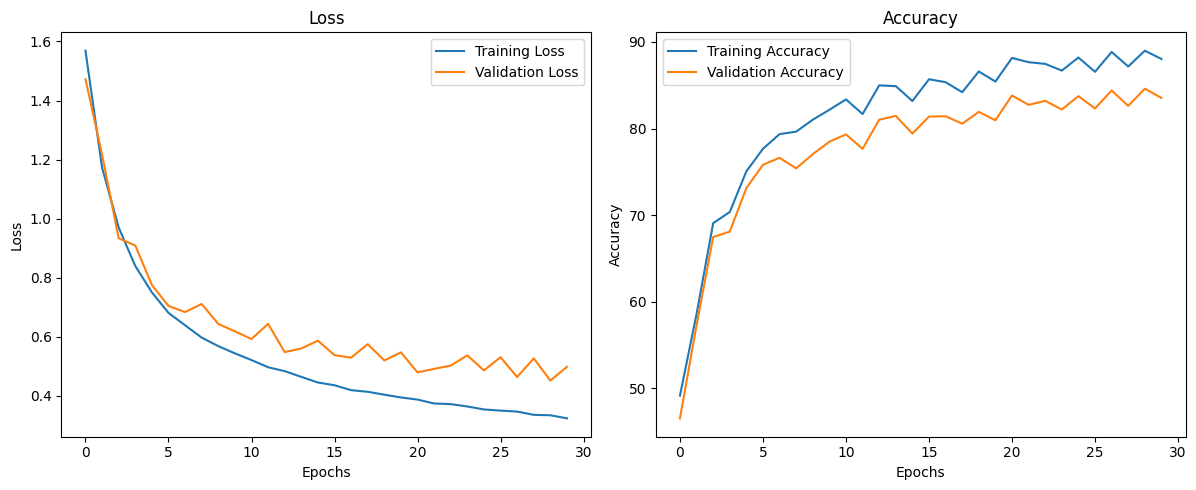

In [ ]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

plot_history(history)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def _compute_confusion_matrix(model, data_loader, device):
    """
    Computes a confusion matrix for the given model and data.
    Uses scikit-learn for robustness and speed.
    """
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            # Move to CPU and convert to list/numpy immediately
            all_targets.extend(targets.view(-1).cpu().numpy())
            all_predictions.extend(predicted_labels.view(-1).cpu().numpy())

    return confusion_matrix(all_targets, all_predictions)

def _plot_confusion_matrix(mat, class_names):
    """
    Visualizes the confusion matrix using Seaborn for professional reporting.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: MobileNetV2 on CIFAR-10')
    plt.show()

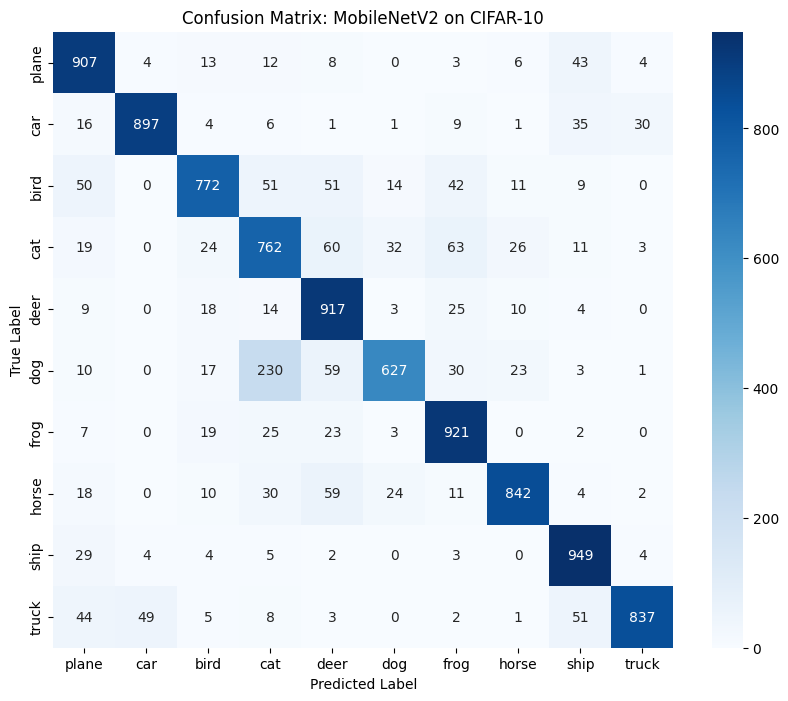

In [ ]:
class_dict = {0: 'plane',
              1: 'car',
              2: 'bird',
              3: 'cat',
              4: 'deer',
              5: 'dog',
              6: 'frog',
              7: 'horse',
              8: 'ship',
              9: 'truck'}
_mat = _compute_confusion_matrix(model=model, data_loader=test_loader, device=device)
_plot_confusion_matrix(_mat, class_names=class_dict.values())

In [ ]:
%watermark -iv

matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

